# Import Required Libraries

In this section, we import the necessary libraries for data manipulation and visualization. We use `pandas` for handling CSV data and `matplotlib` for plotting charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, List

# Define SalesAnalyzer Class

We define the `SalesAnalyzer` class, which provides methods to load sales data, calculate sales metrics, and plot results.

In [2]:
class SalesAnalyzer:
    """
    A class to analyze sales data from a CSV file.

    Methods:
        load_data: Loads sales data from a CSV file.
        get_total_sales: Returns the total sales.
        get_average_sales_per_product: Returns the average sales per product.
        get_top_n_products_by_revenue: Returns the top N products by revenue.
        plot_top_n_products: Plots a bar chart of the top N products by revenue.
    """

    def __init__(self) -> None:
        self.data: Optional[pd.DataFrame] = None

    def load_data(self, filepath: str) -> None:
        """
        Loads sales data from a CSV file.

        Args:
            filepath (str): Path to the CSV file.

        Raises:
            FileNotFoundError: If the file does not exist.
            pd.errors.ParserError: If the file is malformed.
        """
        try:
            self.data = pd.read_csv(filepath)
            if 'product' not in self.data.columns or 'revenue' not in self.data.columns:
                raise ValueError("CSV must contain 'product' and 'revenue' columns.")
        except FileNotFoundError as e:
            print(f"Error: File not found - {filepath}")
            raise e
        except pd.errors.ParserError as e:
            print(f"Error: Malformed CSV file - {filepath}")
            raise e
        except Exception as e:
            print(f"Error: {e}")
            raise e

    def get_total_sales(self) -> float:
        """
        Returns the total sales (sum of revenue).

        Returns:
            float: Total sales.
        """
        if self.data is None:
            raise ValueError("No data loaded.")
        return self.data['revenue'].sum()

    def get_average_sales_per_product(self) -> float:
        """
        Returns the average sales per product.

        Returns:
            float: Average sales per product.
        """
        if self.data is None:
            raise ValueError("No data loaded.")
        return self.data.groupby('product')['revenue'].sum().mean()

    def get_top_n_products_by_revenue(self, n: int = 5) -> pd.DataFrame:
        """
        Returns the top N products by revenue.

        Args:
            n (int): Number of top products to return.

        Returns:
            pd.DataFrame: Top N products by revenue.
        """
        if self.data is None:
            raise ValueError("No data loaded.")
        top_products = (
            self.data.groupby('product')['revenue']
            .sum()
            .sort_values(ascending=False)
            .head(n)
            .reset_index()
        )
        return top_products

    def plot_top_n_products(self, n: int = 5) -> None:
        """
        Plots a bar chart of the top N products by revenue.

        Args:
            n (int): Number of top products to plot.
        """
        top_products = self.get_top_n_products_by_revenue(n)
        plt.figure(figsize=(8, 5))
        plt.bar(top_products['product'], top_products['revenue'], color='skyblue')
        plt.xlabel('Product')
        plt.ylabel('Revenue')
        plt.title(f'Top {n} Products by Revenue')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Load Sales Data from CSV

Use the `load_data` method to load sales data from a CSV file. This method handles exceptions for missing files and malformed data.

In [3]:
analyzer = SalesAnalyzer()
try:
    analyzer.load_data('sales_data.csv')  # Replace with your CSV file path
    print("Sales data loaded successfully.")
except Exception as e:
    print(f"Failed to load sales data: {e}")

Error: File not found - sales_data.csv
Failed to load sales data: [Errno 2] No such file or directory: 'sales_data.csv'


# Get Total Sales

Calculate and display the total sales using the loaded data.

In [4]:
try:
    total_sales = analyzer.get_total_sales()
    print(f"Total Sales: {total_sales:.2f}")
except Exception as e:
    print(f"Error calculating total sales: {e}")

Error calculating total sales: No data loaded.


# Get Average Sales per Product

Compute and display the average sales per product.

In [5]:
try:
    avg_sales = analyzer.get_average_sales_per_product()
    print(f"Average Sales per Product: {avg_sales:.2f}")
except Exception as e:
    print(f"Error calculating average sales: {e}")

Error calculating average sales: No data loaded.


# Get Top N Products by Revenue

Retrieve and display the top N products by revenue.

In [6]:
try:
    top_n = 5
    top_products = analyzer.get_top_n_products_by_revenue(top_n)
    print(f"Top {top_n} Products by Revenue:")
    print(top_products)
except Exception as e:
    print(f"Error retrieving top products: {e}")

Error retrieving top products: No data loaded.


# Handle Exceptions for Missing Files or Malformed Data

Demonstrate how the class handles missing files and malformed data by attempting to load a non-existent or invalid CSV file.

In [7]:
# Example: Handling missing file
try:
    analyzer.load_data('missing_file.csv')
except Exception as e:
    print(f"Handled missing file: {e}")

# Example: Handling malformed data
import io

malformed_csv = io.StringIO("product,revenue\nA,100\nB,not_a_number")
try:
    analyzer.data = pd.read_csv(malformed_csv)
    analyzer.get_total_sales()
except Exception as e:
    print(f"Handled malformed data: {e}")

Error: File not found - missing_file.csv
Handled missing file: [Errno 2] No such file or directory: 'missing_file.csv'


# Plot Bar Chart of Top N Products

Visualize the top N products by revenue using a bar chart.

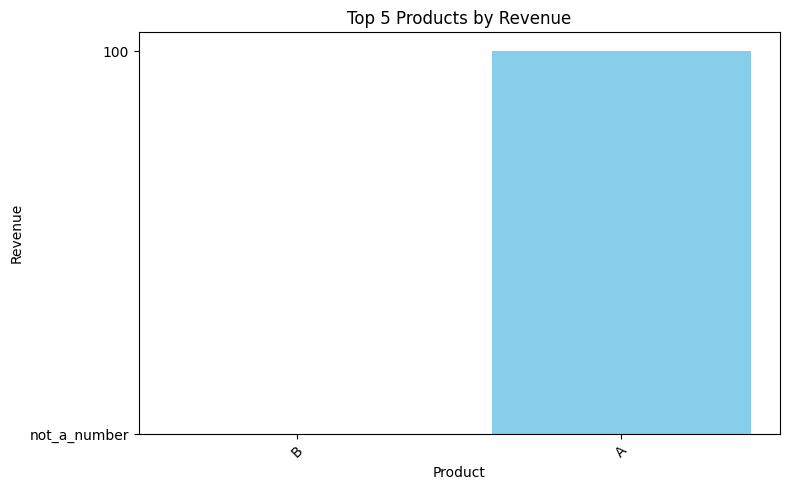

In [8]:
try:
    analyzer.plot_top_n_products(n=5)
except Exception as e:
    print(f"Error plotting top products: {e}")